# ❤️ Heart Disease Prediction Using Machine Learning

## CodeAlpha Machine Learning Internship Project

### 👨‍💻 Developed By
Ganesh Yadav

---

## 📌 Objective

The objective of this project is to predict whether a patient has heart disease using machine learning techniques. A Logistic Regression model is trained on medical data to classify whether a patient is likely to have heart disease or not.

---

## 🛠 Technologies Used

- Python
- Google Colab
- Pandas
- NumPy
- Scikit-learn
- Matplotlib
- Joblib

# Step 1: Import Required Libraries

In this step, all the required Python libraries are imported for data analysis, visualization, machine learning model building, evaluation, and model saving.


In [5]:
import pandas as pd
import numpy as np

In [6]:
print("Pandas Version:", pd.__version__)
print("NumPy Version:", np.__version__)

Pandas Version: 2.2.2
NumPy Version: 2.0.2


# Step 2: Load the Dataset

The Heart Disease dataset is loaded into a Pandas DataFrame using the read_csv() function.

# Step 3: Display Dataset

The first five rows of the dataset are displayed to understand the structure and available features.

In [7]:
df = pd.read_csv("heart.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


# Step 4: Explore the Dataset

The dataset dimensions, data types, and missing values are checked before training the model.

In [8]:
df.shape

(1025, 14)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


# Step 5: Feature Selection

The input features are stored in X and the target variable is stored in y.

In [10]:
X = df.drop("target", axis=1)
y = df["target"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)


Features Shape: (1025, 13)
Target Shape: (1025,)


# Step 6: Split the Dataset

The dataset is divided into training data (80%) and testing data (20%) using train_test_split().

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (820, 13)
Testing Features: (205, 13)
Training Target: (820,)
Testing Target: (205,)


# Step 7: Train the Machine Learning Model

A Logistic Regression classifier is trained using the training dataset.

In [12]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model Training Completed Successfully!")

Model Training Completed Successfully!


# Step 8: Evaluate the Model

The trained model is evaluated using Accuracy, Precision, Recall, F1-Score, and Classification Report.

In [13]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7951219512195122


In [14]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.72      0.78       102
           1       0.76      0.87      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.80      0.79       205



# Step 9: Confusion Matrix

The Confusion Matrix is used to compare the actual values with the predicted values.

In [15]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[73 29]
 [13 90]]


# Step 10: ROC-AUC Score

The ROC-AUC score is calculated to evaluate the model's classification performance.

In [16]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.8770226537216829


# Step 11: ROC Curve

The ROC Curve visually represents the performance of the classifier.

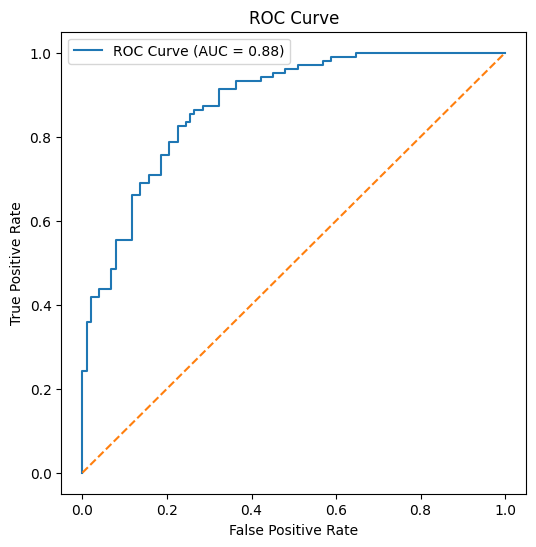

In [17]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Step 12: Save the Trained Model

The trained Logistic Regression model is saved using Joblib for future use.

In [18]:
import joblib

joblib.dump(model, "heart_disease_model.pkl")

print("Model saved successfully!")

Model saved successfully!


# Step 13: Predict on a New Patient

A sample patient's medical information is provided to the trained model to predict whether the patient has heart disease.

In [19]:
import numpy as np

new_patient = np.array([[52, 1, 0, 125, 212, 0, 1, 168, 0, 1.0, 2, 2, 3]])

prediction = model.predict(new_patient)

if prediction[0] == 1:
    print("Prediction: Heart Disease Detected")
else:
    print("Prediction: No Heart Disease")

Prediction: No Heart Disease


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


# ✅ Conclusion

The Logistic Regression model was successfully trained and evaluated for heart disease prediction.

### Final Results

- Accuracy: 79.5%
- Precision: 0.76
- Recall: 0.87
- F1-Score: 0.81
- ROC-AUC Score: 0.88

The trained model achieved good performance and can be used for predicting heart disease based on patient medical information.